In [1]:
import pandas as pd
import datetime as datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = pd.read_csv('hourly_pm2.5_data.csv')

In [2]:
#need to make a fix for missing values! how to do this? Rei said 1/2 DL if missing, hmmmm


In [3]:
df

,Unnamed: 0,state_code,county_code,site_number,parameter_code,poc,latitude,longitude,datum,parameter,...,detection_limit,uncertainty,qualifier,method_type,method,method_code,state,county,date_of_last_change,cbsa_code
0,0,49,35,3006,88101,1,40.736389,-111.872222,WGS84,PM2.5 - Local Conditions,...,2.0,NaN,NaN,FRM,R & P Model 2025 PM2.5 Sequential w/WINS - GRA...,118,Utah,Salt Lake,NaN,41620
1,1,49,35,3006,88101,1,40.736389,-111.872222,WGS84,PM2.5 - Local Conditions,...,2.0,NaN,NaN,FRM,R & P Model 2025 PM2.5 Sequential w/WINS - GRA...,118,Utah,Salt Lake,NaN,41620
2,2,49,35,3006,88101,1,40.736389,-111.872222,WGS84,PM2.5 - Local Conditions,...,2.0,NaN,NaN,FRM,R & P Model 2025 PM2.5 Sequential w/WINS - GRA...,118,Utah,Salt Lake,NaN,41620
3,3,49,35,3006,88101,1,40.736389,-111.872222,WGS84,PM2.5 - Local Conditions,...,2.0,NaN,NaN,FRM,R & P Model 2025 PM2.5 Sequential w/WINS - GRA...,118,Utah,Salt Lake,NaN,41620
4,4,49,35,3006,88101,1,40.736389,-111.872222,WGS84,PM2.5 - Local Conditions,...,2.0,NaN,NaN,FRM,R & P Model 2025 PM2.5 Sequential w/WINS - GRA...,118,Utah,Salt Lake,NaN,41620
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220442,220442,49,35,3006,88101,2,40.736389,-111.872222,WGS84,PM2.5 - Local Conditions,...,2.0,NaN,NaN,FEM,Thermo Scientific Model 5030 SHARP w/VSCC - Be...,184,Utah,Salt Lake,2026-08-11,41620
220443,220443,49,35,3006,88101,2,40.736389,-111.872222,WGS84,PM2.5 - Local Conditions,...,2.0,NaN,NaN,FEM,Thermo Scientific Model 5030 SHARP w/VSCC - Be...,184,Utah,Salt Lake,2026-08-11,41620
220444,220444,49,35,3006,88101,2,40.736389,-111.872222,WGS84,PM2.5 - Local Conditions,...,2.0,NaN,NaN,FEM,Thermo Scientific Model 5030 SHARP w/VSCC - Be...,184,Utah,Salt Lake,2026-08-11,41620
220445,220445,49,35,3006,88101,2,40.736389,-111.872222,WGS84,PM2.5 - Local Conditions,...,2.0,NaN,NaN,FEM,Thermo Scientific Model 5030 SHARP w/VSCC - Be...,184,Utah,Salt Lake,2026-08-11,41620


In [4]:
#merge the data and the time columns
df["date_time_merged"] = df["date_local"] + ' ' + df["time_local"]
#create a proper datetime column
df["date_time"] = pd.to_datetime(df["date_time_merged"])

In [5]:
df["years"] = df["date_time"].dt.year
df["days"] = df["date_time"].dt.day
df["hours"] = df['date_time'].dt.hour
df["months"] = df['date_time'].dt.month
df["day of week"] = df['date_time'].dt.day_of_week
df["day of year"] = df['date_time'].dt.day_of_year


#set a start date so we can track days elapsed
start_date = df["date_time"].iloc[0]

df["date_time_elapsed"] = (df['date_time'] - start_date)

df["days_elapsed"] = df['date_time_elapsed'].dt.days

In [7]:
df.dtypes

Unnamed: 0                         int64
state_code                         int64
county_code                        int64
site_number                        int64
parameter_code                     int64
poc                                int64
latitude                         float64
longitude                        float64
datum                                str
parameter                            str
date_local                           str
time_local                           str
date_gmt                             str
time_gmt                             str
sample_measurement               float64
units_of_measure                     str
units_of_measure_code              int64
sample_duration                      str
sample_duration_code               int64
sample_frequency                     str
detection_limit                  float64
uncertainty                      float64
qualifier                            str
method_type                          str
method          

In [9]:
#df_24houravg = df[df["sample_duration"] == "24 HOUR"]

df_by_day = df.groupby(pd.Grouper(key="date_time", freq= "D"))['sample_measurement'].mean() #measurements grouped by day
df_by_day.head()

#not sure if this is correct, may be improperly joining hourly measurements

date_time
1999-01-01    21.6
1999-01-02    11.1
1999-01-03    15.0
1999-01-04     9.5
1999-01-05    14.7
Freq: D, Name: sample_measurement, dtype: float64

In [ ]:
df_by_day["sample_measurement"].head()

0         21.6
1         11.1
2         15.0
3          9.5
4         14.7
          ... 
210270     7.5
215335     9.7
220423    12.2
215336     9.8
220424    12.0
Name: sample_measurement, Length: 29776, dtype: float64

In [ ]:
type(df_by_day)

pandas.api.typing.DataFrameGroupBy

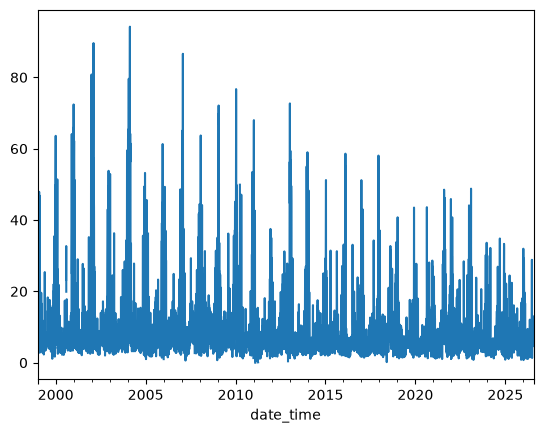

In [ ]:
df_by_day.plot()
plt.show()
plt.close()

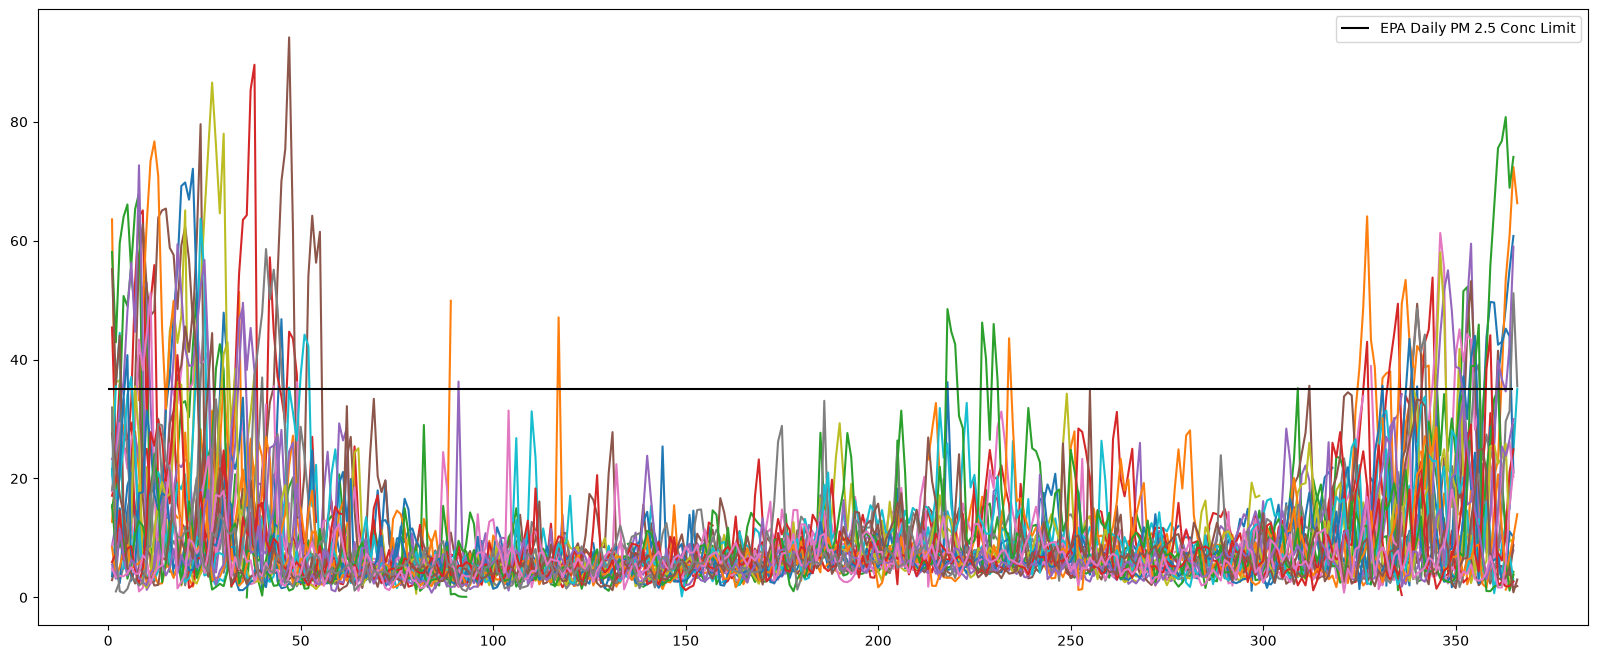

In [37]:
df_by_day = df.groupby(['years', 'day of year'])['sample_measurement'].mean()
df_by_day.head()

df_by_day_flatten = df_by_day.reset_index()
pivoted = df_by_day_flatten.pivot(index = 'day of year', columns = 'years', values='sample_measurement')
fig, ax = plt.subplots(figsize=(20,8))
ax.plot(pivoted)
plt.hlines(
    y=35, xmin = 0, xmax = 365, colors = "black",  label = "EPA Daily PM 2.5 Conc Limit"
)
plt.legend()
plt.show()
# plt.close()

In [49]:
df_exceedance = df_by_day_flatten.groupby("years")["sample_measurement"].agg(lambda x: (x>35).sum())
df_exceedance

years
1999    12
2000    19
2001    25
2002    26
2003     5
2004    36
2005    21
2006    10
2007    18
2008    10
2009    17
2010    15
2011     9
2012     0
2013    31
2014    12
2015     4
2016    10
2017     9
2018     1
2019     2
2020     1
2021    10
2022     3
2023     2
2024     0
2025     0
2026     0
Name: sample_measurement, dtype: int64

In [54]:
df_exceedance= pd.DataFrame(df_exceedance)

In [57]:
df_exceedance.columns

Index(['sample_measurement'], dtype='str')

<BarContainer object of 28 artists>

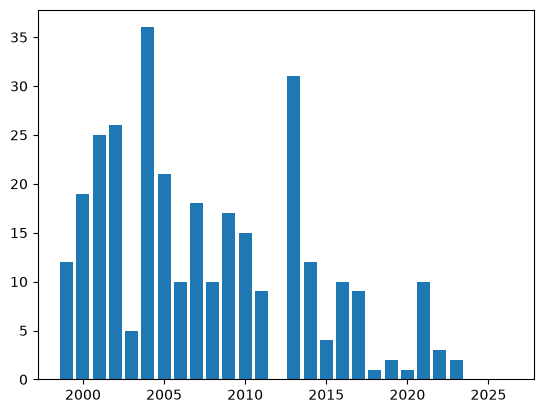

In [58]:
plt.bar(df_exceedance.index, df_exceedance["sample_measurement"])

In [39]:
df_by_day_flatten.where(df_by_day_flatten["sample_measurement"] > 35)

,years,day of year,sample_measurement
0,NaN,NaN,NaN
1,NaN,NaN,NaN
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,NaN,NaN,NaN
...,...,...,...
10051,NaN,NaN,NaN
10052,NaN,NaN,NaN
10053,NaN,NaN,NaN
10054,NaN,NaN,NaN


In [27]:
pivoted

years,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
days,,,,,,,,,,,,,,,,,,,,,
1,9.900000,15.963636,13.730000,17.490909,13.125000,9.033333,6.933333,8.800000,9.483333,7.958333,...,10.771210,7.369730,6.285258,6.129520,9.120990,5.019932,8.769565,10.638527,6.887179,9.699403
2,7.533333,14.527273,11.581818,12.200000,11.633333,10.910000,8.008333,7.800000,10.433333,10.966667,...,10.289060,7.071296,7.364337,5.042910,8.383673,6.308518,7.299320,11.261831,6.881100,5.846647
3,6.422222,16.250000,13.890909,15.775000,9.336364,13.091667,9.127273,9.116667,11.100000,11.350000,...,7.803780,6.893772,9.513472,6.727672,8.960239,6.772991,9.483106,8.074510,5.770515,4.102624
4,7.190000,14.233333,16.581818,16.758333,8.745455,13.325000,9.575000,8.175000,12.627273,6.683333,...,6.024532,9.515071,11.671053,8.211257,9.748810,7.520478,8.524403,9.451171,6.310940,4.824198
5,9.350000,11.200000,15.025000,17.525000,8.090909,13.327273,9.008333,9.791667,14.675000,8.058333,...,7.691823,9.909043,10.917376,9.039254,7.745884,5.996088,7.698270,7.881849,6.514082,5.990671
6,11.600000,13.040000,12.316667,17.700000,8.509091,13.658333,9.272727,11.533333,14.281818,7.708333,...,9.158419,11.620968,6.191207,11.142246,11.065271,7.225565,5.604974,7.051379,5.446794,6.619242
7,8.763636,11.933333,9.836364,19.383333,10.236364,13.308333,8.083333,12.650000,12.236364,8.890909,...,9.433156,9.907447,5.922883,11.289048,12.869165,8.277143,5.401706,7.897518,5.489673,5.562865
8,7.463636,13.118182,12.963636,13.391667,10.345455,13.650000,7.333333,11.275000,10.600000,7.927273,...,8.619857,9.201950,8.017108,6.857377,11.177226,7.597248,6.152479,8.999130,6.077172,5.675439
9,7.510000,9.060000,14.175000,14.854545,10.841667,16.316667,9.009091,9.050000,11.720000,7.733333,...,6.863555,9.425993,7.229289,6.727500,10.013776,8.353804,5.633448,6.819658,6.005272,3.996210
